## Описание исследования
Заказчик нашего исследования — Министерство культуры Российской Федерации. 
Нам нужно изучить рынок российского кинопроката и выявить текущие тренды. Уделить внимание фильмам, которые получили государственную поддержку. Попробуем ответить на вопрос, насколько такие фильмы интересны зрителю. 
Мы будем работать с данными, опубликованными на портале открытых данных Министерства культуры. Набор данных содержит информацию о прокатных удостоверениях, сборах и государственной поддержке фильмов, а также информацию с сайта КиноПоиск. 

Исследование пройдет в 5 этапов <br> 1) Загрузка двух наборов сырых данных в два разных датасета и их дальнейшее объединение. <br>2) Предобработка данных.<br>3) Исследовательский анализ.<br> 4) Анализ фильмов, которые получили государственную поддержку <br> 5) Общий вывод.

## Документация

Таблица mkrf_movies содержит информацию из реестра прокатных удостоверений. <br> У одного фильма может быть несколько прокатных удостоверений. <br> title — название фильма<br> puNumber — номер прокатного удостоверения <br>show_start_date — дата премьеры фильма <br> type — тип фильма <br> film_studio — студия-производитель <br> production_country — страна-производитель <br> director — режиссёр <br> producer — продюсер <br> age_restriction — возрастная категория <br> refundable_support — объём возвратных средств государственной поддержки <br> nonrefundable_support — объём невозвратных средств государственной поддержки <br> financing_source — источник государственного финансирования <br> budget — общий бюджет фильма <br> ratings — рейтинг фильма на КиноПоиске <br> genres — жанр фильма. <br> Обратите внимание, что столбец budget уже включает в себя полный объём государственной поддержки. Данные в этом столбце указаны только для тех фильмов, которые получили государственную поддержку. <br> Таблица mkrf_shows содержит сведения о показах фильмов в российских кинотеатрах. <br> puNumber — номер прокатного удостоверения <br> box_office — сборы в рублях.

## Исследование данных о российском кинопрокате



### Обзор  данных


In [1]:
import pandas as pd # импорт пандас
import matplotlib.pyplot as plt # импорт матплот

data_one = pd.read_csv("/datasets/mkrf_movies.csv") # перевод данных о прокатных удостоверениях в датафрейм
data_two = pd.read_csv("/datasets/mkrf_shows.csv") # перевод данных о прокате в российских кинотеатрах.

display(data_one.head(), data_two.head()) # просмотр первых строк датафреймов 
data_one.info() # просмотр информации датафрейме
print("--------------------------------------------------")
data_two.info() # просмотр информации о датафрейме



,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


,puNumber,box_office
0,111000113,2.450000e+03
1,111000115,6.104000e+04
2,111000116,1.530300e+08
3,111000117,1.226096e+07
4,111000118,1.636841e+08


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

In [2]:
data_one[~data_one["puNumber"].str.isdigit()] # поиск строк с аномалиями 

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
804,Паранормальный Якутск,111004112,2012-08-24T12:00:00.000Z,Художественный,ИП Тимофеев К.П.,Россия,К.Тимофеев,NaN,«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,NaN,NaN
1797,Курбан-роман. (История с жертвой),нет,2014-05-15T12:00:00.000Z,Художественный,"ФОНД ""ИННОВАЦИЯ""",Россия,С.Юзеев,М.Галицкая,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN


При попытке объединить таблицы столкнулись с проблемой разных типов данных и некоректных значений в некоторых строках. Для объединения датасетов нужно привести значения к единому типу данных и избавиться от аномалий. Обнаружены две строки с аномалиями, прежде чем приводить данные к одному типу разберемся сначала с ними. Для удаления некорректных символов можно воспользоваться значением-заглушкой "0"

In [3]:
data_one.loc[804, "puNumber"] = data_one.loc[804, "puNumber"].strip() # удаление пробелов 
data_one.loc[1797, "puNumber"] = "0" # замена на нулевое значение 

data_one["puNumber"] = pd.to_numeric(data_one["puNumber"]) # преобразование


In [4]:
merged_data = data_one.merge(data_two, how = "left") # объединение 
display(merged_data.head(20)) # проверка результата 

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
5,Остановился поезд,111013816,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,NaN
6,Любовь и голуби,111007013,2013-10-18T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.0
7,Любовь и сигареты,221074614,2014-12-29T12:00:00.000Z,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.6,"мюзикл,мелодрама,комедия",NaN
8,Отпетые мошенники.,121011416,2016-05-05T12:00:00.000Z,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,8.0,"комедия,криминал",NaN
9,Отпуск за свой счет,111019114,2014-12-01T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.8,"мелодрама,комедия",NaN


Исходные датасеты объеденены в один общий. 

### Предобработка данных

#### Шаг 2.1. Проверка типа данных

In [5]:
display(merged_data.describe()) # вывод информаии о датасете
merged_data.info() # вывод информации о датасете

str_ratings = merged_data[merged_data["ratings"].str.contains("[^0-9.]").fillna(False)] # поиск пробленых строк
# display(str_raiting) проверка результата

merged_data.loc[str_ratings.index, "ratings"] = str_ratings["ratings"].str[0] + "." + str_ratings["ratings"].str[1]


,puNumber,refundable_support,nonrefundable_support,budget,box_office
count,7.486000e+03,3.320000e+02,3.320000e+02,3.320000e+02,3.158000e+03
mean,1.351785e+08,1.186446e+07,4.898099e+07,1.272297e+08,7.647870e+07
std,3.838218e+07,2.491656e+07,5.998012e+07,1.885883e+08,2.403531e+08
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.120250e+08,0.000000e+00,2.500000e+07,4.200000e+07,8.623900e+04
50%,1.210155e+08,0.000000e+00,3.000000e+07,6.864992e+07,2.327988e+06
75%,1.240033e+08,1.500000e+07,4.037500e+07,1.419853e+08,2.397967e+07
max,2.310011e+08,1.800000e+08,4.000000e+08,2.305074e+09,3.073569e+09


<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   int64  
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

In [6]:
merged_data["ratings"] = pd.to_numeric(merged_data["ratings"]) # преобразование

In [7]:
merged_data["show_start_date"] = pd.to_datetime(merged_data["show_start_date"], format = "%Y-%m-%dT%H:%M:%S.%fZ")
display(merged_data.head(20)) # проверка результата

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
5,Остановился поезд,111013816,2016-09-13 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,NaN
6,Любовь и голуби,111007013,2013-10-18 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.0
7,Любовь и сигареты,221074614,2014-12-29 12:00:00,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.6,"мюзикл,мелодрама,комедия",NaN
8,Отпетые мошенники.,121011416,2016-05-05 12:00:00,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,NaN,NaN,NaN,NaN,8.0,"комедия,криминал",NaN
9,Отпуск за свой счет,111019114,2014-12-01 12:00:00,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,NaN,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,7.8,"мелодрама,комедия",NaN


Полученная ранее информация о датасете позволяет сделать вывод что информация в столбцах "raitings" и "show_start_date" хранится в строковом формате. Часть информации о рейтинге картин хранится в процентном значении, для дальнейшей работы надо привести к единому бальному значению. Значения из столбца "show_start_date" нужно перевести в формат "%Y-%m-%dT%H:%M:%S.%fZ"


####  Поиск пропусков


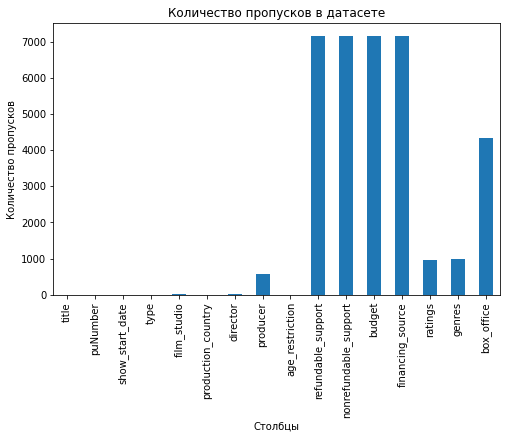

In [8]:
merged_data.isna().sum().plot(kind = "bar", figsize = (8, 5)) # поиск пропусков, построим гистограмму для наглядности
plt.xlabel("Столбцы")
plt.ylabel("Количество пропусков")
plt.title("Количество пропусков в датасете")
plt.show()

In [9]:
merged_data["refundable_support"] = merged_data["refundable_support"].fillna(0) # убираем пропуски
merged_data["nonrefundable_support"] = merged_data["nonrefundable_support"].fillna(0) # убираем пропуски 
merged_data["financing_source"] = merged_data["financing_source"].fillna("отсутствует") # убираем пропуски

# display(merged_data.head(20)) # проверка результата

Первое что бросается в глаза это колонки "refundable_support" "nonrefundable_support", "budget", "financing_source", одинаковое количество пропусков, если верить документации все столбцы связаны с государественным финансированием. Также в документации указано "budget уже включает в себя полный объём государственной поддержки. Данные в этом столбце указаны только для тех фильмов, которые получили государственную поддержку". Отсутствие информации в столбцах может быть маркером отсутствия финансирования со стороны государства. Заменим пропуски на соответствующие значения. В случае с столбцом "box_office" сложно предложить какое либо решение, у нас нет необходимых данных и вряд ли пропуски можно восполнить за счет других столбцов датасета, поэтому лучше оставить как есть.

In [10]:
merged_data["genres"] = merged_data["genres"].fillna("отсутствует") # замена пропусков 
merged_data["film_studio"] = merged_data["film_studio"].fillna("отсутствует") # замена пропусков 
merged_data["production_country"] = merged_data["production_country"].fillna("отсутствует") # замена пропусков 
merged_data["director"] = merged_data["director"].fillna("отсутствует") # замена пропусков 
merged_data["producer"] = merged_data["producer"].fillna("отсутствует") # замена пропусков 

display(merged_data.head(50)) # проверим что получилось

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,отсутствует,«6+» - для детей старше 6 лет,0.0,0.0,NaN,отсутствует,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN
5,Остановился поезд,111013816,2016-09-13 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,отсутствует,«6+» - для детей старше 6 лет,0.0,0.0,NaN,отсутствует,7.7,драма,NaN
6,Любовь и голуби,111007013,2013-10-18 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,отсутствует,«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,8.3,"мелодрама,комедия",2700.0
7,Любовь и сигареты,221074614,2014-12-29 12:00:00,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.6,"мюзикл,мелодрама,комедия",NaN
8,Отпетые мошенники.,121011416,2016-05-05 12:00:00,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,8.0,"комедия,криминал",NaN
9,Отпуск за свой счет,111019114,2014-12-01 12:00:00,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,отсутствует,«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,7.8,"мелодрама,комедия",NaN


В столбце "genres" есть фильмы без указания жанра, заменим пропуски на соответствующую подпись, аналогичным образом поступим с столбцами "film_studio", "production_country", "director", и "producer" так как у нас нет ничего на что бы мы могли заменить пропуски

#### Поиск дубликатов

In [11]:
merged_data.duplicated().sum() # поиск явных дубликатов

0

Явные дубликаты не обнаружены. Далее рассмотрим столбцы на наличие неявных дубликатов. Рассмотрим уникальные значения и общее количество если они не равны, вероятно, в данных есть неявные дубликаты

In [12]:
merged_data["title"].nunique() # поиск неявных дубликатов

6772

In [13]:
merged_data[merged_data["title"].duplicated()] # просмотр дубликатов в названии

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
3,Особо опасен,221026916,2016-06-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN
41,Алекс и Эмма,221004616,2016-02-09 12:00:00,Художественный,"Эскейп Артистс, Франчайз Пикчерз, Рейнер-Грэйс...",США,Роб Райнер,"Тодд Блэк, Элан Грейсман, Джереми Левен, Роб Р...",«16+» - для детей старше 16 лет,0.0,0.0,NaN,отсутствует,6.4,"мелодрама,комедия",NaN
110,Гарри Поттер и орден Феникса /По роману Дж.К.Р...,121026316,2016-09-23 12:00:00,Художественный,"Уорнер Бразерс, Хэйдей Филмз",США - Великобритания,Дэвид Йетс,"Дэйвид Баррон, Дэйвид Хейман",«16+» - для детей старше 16 лет,0.0,0.0,NaN,отсутствует,7.7,"фэнтези,приключения,семейный",759526.00
113,Гарри Поттер и узник Азкабана /По роману Дж.К....,121026116,2016-09-23 12:00:00,Художественный,"Хэйдей Филмз, 1492 Пикчерз, Уорнер Бразерс",США,Альфонсо Куарон,Майкл Барната,«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,8.2,"фэнтези,приключения,семейный",1125302.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7369,Невиновен,111019319,2019-11-07 12:00:00,Художественный,"ООО ""Кавказфильм""",Россия,А.Емкужев,"А.Емкужев, А.Хуажева, ООО ""Корпорация Русская ...",«16+» - для детей старше 16 лет,0.0,0.0,NaN,отсутствует,7.5,"триллер,детектив,криминал",NaN
7416,"Отель ""Гранд Будапешт""",121035119,2019-12-13 12:00:00,Художественный,"Американ Эмпирикал, Индиан Пэинтбраш, Скотт Ру...","Германия, США",Уэс Андерсен,"Уэс Андерсон, Джереми Доусон, Стивен Рейлс",«16+» - для детей старше 16 лет,0.0,0.0,NaN,отсутствует,7.9,"комедия,приключения,детектив",NaN
7438,Зверь,121035919,2019-12-05 12:00:00,Художественный,Студио энд Нью,Южная Корея,Ли Джон-хо,"Чан Гён-ик, Чон Джи-хун, Пэк Кён сук",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.5,"триллер,драма",175003.51
7450,В тихом омуте,121036919,2019-12-09 12:00:00,Художественный,"Хэд Гир Филмз, Крео Филмз, Локал Хироу, Метрол...",США,Адам Рэндолл,Мэтт Уолдек,«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"триллер,криминал,детектив",NaN


In [15]:
merged_data.query('title == "Особо опасен"') # рассмотрим "Особо опасен" 

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
2,Особо опасен,221038416,2016-10-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN


Информация в строках совпадает кроме лицензии и даты показа. Вероятно это просто разные показы одного и того же фильма.

In [16]:
merged_data.query('title == "Алекс и Эмма"') # рассмотрим более детально "Алекс и Эмма"

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
40,Алекс и Эмма,221005015,2015-02-25 12:00:00,Художественный,"Эскейп Артистс, Франчайз Пикчерз, Рейнер-Грэйс...",США,Роб Райнер,"Тодд Блэк, Элан Грейсман, Джереми Левен, Роб Р...",«16+» - для детей старше 16 лет,0.0,0.0,NaN,отсутствует,6.4,"мелодрама,комедия",NaN
41,Алекс и Эмма,221004616,2016-02-09 12:00:00,Художественный,"Эскейп Артистс, Франчайз Пикчерз, Рейнер-Грэйс...",США,Роб Райнер,"Тодд Блэк, Элан Грейсман, Джереми Левен, Роб Р...",«16+» - для детей старше 16 лет,0.0,0.0,NaN,отсутствует,6.4,"мелодрама,комедия",NaN
4581,Алекс и Эмма,221156910,2010-12-17 12:00:00,Художественный,"Эскейп Артистс, Франчайз Пикчерз, Рейнер-Грэйс...",США,Роб Райнер,"Тодд Блэк, Элан Грейсман, Джереми Левен, Роб Р...",«16+» - для детей старше 16 лет,0.0,0.0,NaN,отсутствует,6.4,"мелодрама,комедия",NaN


Ситуация идентична предыдущему срезу. Лицензия и даты отличаюся, остальное то же самое.

In [17]:
merged_data.query('title == "Зверь"') # рассмотрим "зверь" более детально

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
5988,Зверь,121013518,2018-07-05 12:00:00,Художественный,"Агиле Филмз, Бэ Эф И, Фильм Фонд, Филм Фо, Стр...",Великобритания,Майкл Пирс,"Кристиан Броуди, Лорен Дарк, Ивана МакКиннон",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.5,"триллер,драма",5544612.00
7438,Зверь,121035919,2019-12-05 12:00:00,Художественный,Студио энд Нью,Южная Корея,Ли Джон-хо,"Чан Гён-ик, Чон Джи-хун, Пэк Кён сук",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.5,"триллер,драма",175003.51


В данном случае ситуация обратная, все значения в строках отличаются кроме названия, скорее всего это две разные картины

In [18]:
merged_data.query('title == "Вторжение"') # рассмотрим ближе "Вторжение"

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
5430,Вторжение,124002417,2017-08-01 12:00:00,Анимационный,Баобаб Студиос,США,Эрик Дарнелл,отсутствует,«6+» - для детей старше 6 лет,0.0,0.0,NaN,отсутствует,5.7,"фантастика,боевик",NaN
7474,Вторжение,111022519,2019-12-23 12:00:00,Художественный,"ООО ""Арт Пикчерс Студия"", ООО ""Водород 2011""",Россия,Ф.Бондарчук,"Ф.Бондарчук, М.Врубель, А.Андрющенко, Д.Рудовский",«12+» - для детей старше 12 лет,100000000.0,400000000.0,944000000.0,Фонд кино,5.7,"фантастика,боевик",NaN


Снова одинаковые названия но разные фильмы.

In [19]:
merged_data[merged_data["puNumber"].duplicated()] # рассмотрим подробнее столбец "PuNumber"

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
4639,Иоанна - женщина на папском престоле /По роман...,221154310,2010-12-17 12:00:00,Художественный,"Константин Фильм, А Эр Ди Дегето Фильм, Дюне ...",Германия - Великобритания - Италия - Испания,Зенке Вортманн,"Оливер Бербен, Дорис Д.Хайнце, Фарук Элтан",«16+» - для детей старше 16 лет,0.0,0.0,NaN,отсутствует,7.6,"драма,мелодрама,история",NaN
5068,Анализируй то!,221054410,2010-05-25 12:00:00,Художественный,"Уорнер Бразерс, Виллидж Роадшоу Пикчерз, Эн-Пи...",США,Гарольд Реймис,"Джейн Розенталь, Паул Уэйнстейн",«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,6.8,"комедия,криминал",NaN


Номер лицензии один и тот же, остальные значения отлчиаются, судя по всему, это совершенно разные фильмы. 

In [20]:
# merged_data["production_country"].unique() # рассмотрим столбец страны проихводства более подробно
merged_data["production_country"] = merged_data["production_country"].str.replace('-', ', ') # меняю "-" на ","
merged_data["production_country"].unique() # проверка резульата

array(['США', 'СССР', 'Франция', 'СССР, Венгрия',
       'Германия, Великобритания', 'Великобритания ,  Италия',
       'Чехословакия', 'США ,  Франция ,  Турция', 'Новая Зеландия',
       'Канада ,  Франция ,  Испания', 'США, Германия',
       'США ,  Великобритания', 'Великобритания', 'США ,  Германия',
       'Франция ,  Мексика ,  США', 'Россия, Казахстан, США',
       'СССР, Швеция', 'СССР, Франция, Англия, Куба, ГДР', 'Германия',
       'Великобритания, США, Германия, КНР',
       'СССР, ЧССР, Западный Берлин, ПНР', 'СССР, Италия', 'Гонконг, КНР',
       'США ,  Франция', 'США ,  Япония ,  Франция ,  Великобритания',
       'Гонконг ,  Сингапур ,  Таиланд ,  Великобритания', 'США, Канада',
       'Франция ,  Италия ,  Великобритания ,  США', 'Франция ,  США',
       'Ирландия, Великобритания, Германия', 'Чехия', 'США, Австралия',
       'СССР, Финляндия', 'США, Франция, Великобритания, Австрия',
       'США ,  Бельгия', 'США ,  Ирландия ,  Великобритания',
       'Великобритания 

В глаза бросаются символы - разделители, некоторые значения разделены запятой, некоторые разделены тире. Попробую привести все разделители к ","

####  Изучение категориальных значений

In [21]:
# merged_data["type"].value_counts() # просмотрим значения столбца "type"
merged_data["type"] = merged_data["type"].str.strip() # удаление пробелов
merged_data["type"].value_counts() # проверка результата

Художественный                5909
Анимационный                   829
Прочие                         406
Документальный                 288
Научно-популярный               53
Музыкально-развлекательный       1
Name: type, dtype: int64

В данных есть лишние пробелы, удалю их

In [22]:
merged_data["genres"].value_counts() # перейдем к столбцу "genres"

отсутствует                        976
драма                              476
комедия                            352
мелодрама,комедия                  222
драма,мелодрама,комедия            189
                                  ... 
ужасы,триллер,мелодрама              1
комедия,военный,музыка               1
ужасы,драма,военный                  1
приключения,детский                  1
документальный,комедия,криминал      1
Name: genres, Length: 743, dtype: int64

Кажется с столбцом все в порядке. Оставлю без изменений

In [23]:
merged_data["age_restriction"].value_counts() # переходим к столбцу "age restriction"

«16+» - для детей старше 16 лет           2851
«18+» - запрещено для детей               1605
«12+» - для детей старше 12 лет           1593
«0+» - для любой зрительской аудитории     811
«6+» - для детей старше 6 лет              626
Name: age_restriction, dtype: int64

Кажется что с данным столбцом все в порядке.

In [24]:
# merged_data["film_studio"].value_counts() # переходим к "film studio"
# merged_data["film_studio"].nunique() проверим кол-во
merged_data["film_studio"] = merged_data["film_studio"].str.strip() # удаляю пропуски
merged_data["film_studio"].nunique() # провера результата

5463

Удалил пробелы.

In [25]:
# merged_data["director"].value_counts() # переходим к столбцу "director"
# merged_data["director"].unique() # просмотр уникальных значений
# merged_data["director"].nunique() # посмотрим на кол-во
merged_data["director"] = merged_data["director"].str.strip() # удаление пропусков
merged_data["director"].nunique() # проверка

4802

Снова обнаружены пробелы

In [26]:
# merged_data["producer"].value_counts() # переходим к столбцу "producer"
# merged_data["producer"].unique() № просмотр уникальных значений
# merged_data["producer"].nunique() # посмотрим кол-во
merged_data["producer"] = merged_data["producer"].str.strip() # удаляем пропуски
merged_data["producer"].nunique() # проверка результата 

5335

Пробелы удалены

In [27]:
# merged_data["title"].value_counts() # переходим к столбцу "title"
# merged_data["title"].unique()
# merged_data["title"].nunique() # посмотрим кол-во
merged_data["title"] = merged_data["title"].str.strip() # попробую удалить пропуски
merged_data["title"].nunique() # проверю результат после удаления

6772

С столбцом все в порядке

Проблема категориальных столбцов заключается в произвольном формате данных: значения могут быть записаны с различными знаками и в одной строке перечислены несколько элементов. Это затрудняет обработку данных и выявление неявных дубликатов, что приводит к большому количеству уникальных значений, содержащих скрытые дубликаты.

#### Проверка количественных значений

In [28]:
display(merged_data.head(50)) # осмотрим таблицу полностью
display(merged_data["budget"].value_counts()) # осмотрим столбец

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,отсутствует,«6+» - для детей старше 6 лет,0.0,0.0,NaN,отсутствует,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN
5,Остановился поезд,111013816,2016-09-13 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,отсутствует,«6+» - для детей старше 6 лет,0.0,0.0,NaN,отсутствует,7.7,драма,NaN
6,Любовь и голуби,111007013,2013-10-18 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,отсутствует,«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,8.3,"мелодрама,комедия",2700.0
7,Любовь и сигареты,221074614,2014-12-29 12:00:00,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.6,"мюзикл,мелодрама,комедия",NaN
8,Отпетые мошенники.,121011416,2016-05-05 12:00:00,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,8.0,"комедия,криминал",NaN
9,Отпуск за свой счет,111019114,2014-12-01 12:00:00,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,отсутствует,«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,7.8,"мелодрама,комедия",NaN


0.0            17
38000000.0      6
80000000.0      4
50000000.0      4
40000000.0      3
               ..
49280496.0      1
56693559.0      1
57166797.0      1
109814241.0     1
42252509.0      1
Name: budget, Length: 290, dtype: int64

Можно попробовать осмотреть отдельно строки где значения столбца не равны нулю, поискать связь там.

In [29]:
merged_data_bud = merged_data.loc[((merged_data["financing_source"] != "отсутствует") & (merged_data["budget"] != 0))] # создание отдельной таблицы
display(merged_data_bud.head(50)) # посмотрим результат


,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
1281,Пока еще жива,111005313,2013-10-11 12:00:00,Художественный,"АНО содействия развитию кинематографии ""Ангел-...",Россия,А.Атанесян,"А.Атанесян, М.Бабаханов, Р.Бутко",«16+» - для детей старше 16 лет,0.0,26500000.0,79411900.0,Министерство культуры,8.1,"драма,мелодрама",3.653536e+05
1448,Бесславные придурки,111003314,2014-03-28 12:00:00,Художественный,"ООО ""Компания ""АТК-Студио""",Россия,А.Якимчук,А.Тютрюмов,«12+» - для детей старше 12 лет,0.0,26000000.0,37142857.0,Министерство культуры,NaN,отсутствует,2.814000e+04
1498,Невидимки,111004213,2013-09-10 12:00:00,Художественный,"ООО ""Компания ""РЕАЛ-ДАКОТА""",Россия,"Р.Давлетьяров, С.Комаров","Р.Давлетьяров, А.Котелевский, А.Олейников",«12+» - для детей старше 12 лет,0.0,107847945.0,176023490.0,Фонд кино,5.3,"комедия,фантастика",1.995703e+07
1524,БЕРЦЫ,111004314,2014-05-05 12:00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,Е.Миндадзе (псевдоним Катя Шагалова),Л.Антонова,«16+» - для детей старше 16 лет,0.0,28000000.0,40574140.0,Министерство культуры,4.2,драма,5.591750e+04
1792,Братья Ч,111004414,2014-04-23 12:00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,М.Угаров,"А.Миндадзе, Л.Антонова",«16+» - для детей старше 16 лет,0.0,25000000.0,40015122.0,Министерство культуры,6.4,драма,2.321000e+05
1854,Тайна Сухаревой башни. Чародей равновесия,114000115,2015-02-18 12:00:00,Анимационный,"ООО ""Студия ""Мастер-Фильм""",Россия,С.Серегин,А.Герасимов,«6+» - для детей старше 6 лет,0.0,25000000.0,51850000.0,Министерство культуры,6.1,"мультфильм,фэнтези,история",1.507886e+07
1870,А зори здесь тихие..._,111002915,2015-03-16 12:00:00,Художественный,"ООО ""Компания ""Реал-Дакота""",Россия,Р.Давлетьяров,отсутствует,«12+» - для детей старше 12 лет,50000000.0,100000000.0,220588394.0,Фонд кино,8.5,"драма,военный,история",2.491668e+08
1871,Две женщины,111013714,2014-10-02 12:00:00,Художественный,"ООО ""Продюсерский Центр ""Хорошо Продакшн"", Rez...","Россия, Франция, Латвия",В.Глаголева,Н.Иванова,«12+» - для детей старше 12 лет,0.0,46502299.0,86210067.0,"Министерство культуры, Фонд кино",6.7,драма,4.731240e+06
1903,Призрак_.,111001815,2015-03-02 12:00:00,Художественный,"ООО ""Водород 2011""",Россия,А.Войтинский,С.Сельянов,«6+» - для детей старше 6 лет,0.0,75000000.0,139551503.0,Фонд кино,7.0,"триллер,боевик,приключения",3.528043e+08
1912,Ведьма .,111002215,2015-03-05 12:00:00,Художественный,"ООО ""Кинокомпания ""Ракурс""",Россия,Д.Федоров,В.Сидоренко,«16+» - для детей старше 16 лет,0.0,34000000.0,48571430.0,Министерство культуры,7.4,"фэнтези,приключения,драма",5.190750e+04


In [30]:
coefficient = ((merged_data_bud["refundable_support"] + merged_data_bud["nonrefundable_support"]) * 100 / merged_data_bud["budget"]).mean()
print(coefficient) # расчет коэффициента поддержки от общего бюджета

51.73858197698938


In [31]:
mask = (merged_data_bud["financing_source"] != "отсутствует") & (merged_data_bud["budget"] == 0)
merged_data_bud.loc[mask, "budget"] = ((merged_data_bud["refundable_support"] + merged_data_bud["nonrefundable_support"]) * 100 / coefficient)
# заполнение нулевых значений

In [32]:
update_merged_data_bud = merged_data_bud[merged_data_bud["financing_source"] != "отсутствует"].copy() # создание новой таблицы 
display(update_merged_data_bud.head(25)) # проверка результата

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
1281,Пока еще жива,111005313,2013-10-11 12:00:00,Художественный,"АНО содействия развитию кинематографии ""Ангел-...",Россия,А.Атанесян,"А.Атанесян, М.Бабаханов, Р.Бутко",«16+» - для детей старше 16 лет,0.0,26500000.0,79411900.0,Министерство культуры,8.1,"драма,мелодрама",365353.6
1448,Бесславные придурки,111003314,2014-03-28 12:00:00,Художественный,"ООО ""Компания ""АТК-Студио""",Россия,А.Якимчук,А.Тютрюмов,«12+» - для детей старше 12 лет,0.0,26000000.0,37142857.0,Министерство культуры,NaN,отсутствует,28140.0
1498,Невидимки,111004213,2013-09-10 12:00:00,Художественный,"ООО ""Компания ""РЕАЛ-ДАКОТА""",Россия,"Р.Давлетьяров, С.Комаров","Р.Давлетьяров, А.Котелевский, А.Олейников",«12+» - для детей старше 12 лет,0.0,107847945.0,176023490.0,Фонд кино,5.3,"комедия,фантастика",19957031.5
1524,БЕРЦЫ,111004314,2014-05-05 12:00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,Е.Миндадзе (псевдоним Катя Шагалова),Л.Антонова,«16+» - для детей старше 16 лет,0.0,28000000.0,40574140.0,Министерство культуры,4.2,драма,55917.5
1792,Братья Ч,111004414,2014-04-23 12:00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,М.Угаров,"А.Миндадзе, Л.Антонова",«16+» - для детей старше 16 лет,0.0,25000000.0,40015122.0,Министерство культуры,6.4,драма,232100.0
1854,Тайна Сухаревой башни. Чародей равновесия,114000115,2015-02-18 12:00:00,Анимационный,"ООО ""Студия ""Мастер-Фильм""",Россия,С.Серегин,А.Герасимов,«6+» - для детей старше 6 лет,0.0,25000000.0,51850000.0,Министерство культуры,6.1,"мультфильм,фэнтези,история",15078858.6
1870,А зори здесь тихие..._,111002915,2015-03-16 12:00:00,Художественный,"ООО ""Компания ""Реал-Дакота""",Россия,Р.Давлетьяров,отсутствует,«12+» - для детей старше 12 лет,50000000.0,100000000.0,220588394.0,Фонд кино,8.5,"драма,военный,история",249166767.7
1871,Две женщины,111013714,2014-10-02 12:00:00,Художественный,"ООО ""Продюсерский Центр ""Хорошо Продакшн"", Rez...","Россия, Франция, Латвия",В.Глаголева,Н.Иванова,«12+» - для детей старше 12 лет,0.0,46502299.0,86210067.0,"Министерство культуры, Фонд кино",6.7,драма,4731239.5
1903,Призрак_.,111001815,2015-03-02 12:00:00,Художественный,"ООО ""Водород 2011""",Россия,А.Войтинский,С.Сельянов,«6+» - для детей старше 6 лет,0.0,75000000.0,139551503.0,Фонд кино,7.0,"триллер,боевик,приключения",352804320.4
1912,Ведьма .,111002215,2015-03-05 12:00:00,Художественный,"ООО ""Кинокомпания ""Ракурс""",Россия,Д.Федоров,В.Сидоренко,«16+» - для детей старше 16 лет,0.0,34000000.0,48571430.0,Министерство культуры,7.4,"фэнтези,приключения,драма",51907.5


In [33]:
update_merged_data_bud.loc[((update_merged_data_bud["financing_source"] != "отсутствует") & (update_merged_data_bud["budget"] == 0))].count().sum()
# проверка заполнения

0

In [34]:
merged_data.describe() # просмотр общей информации

,puNumber,refundable_support,nonrefundable_support,budget,ratings,box_office
count,7.486000e+03,7.486000e+03,7.486000e+03,3.320000e+02,6519.000000,3.158000e+03
mean,1.351785e+08,5.261822e+05,2.172280e+06,1.272297e+08,6.488173,7.647870e+07
std,3.838218e+07,5.781108e+06,1.614894e+07,1.885883e+08,1.114638,2.403531e+08
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,0.000000e+00
25%,1.120250e+08,0.000000e+00,0.000000e+00,4.200000e+07,5.900000,8.623900e+04
50%,1.210155e+08,0.000000e+00,0.000000e+00,6.864992e+07,6.600000,2.327988e+06
75%,1.240033e+08,0.000000e+00,0.000000e+00,1.419853e+08,7.200000,2.397967e+07
max,2.310011e+08,1.800000e+08,4.000000e+08,2.305074e+09,9.900000,3.073569e+09


In [35]:
merged_data.query("puNumber == 0") # просмотр строки

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
1797,Курбан-роман. (История с жертвой),0,2014-05-15 12:00:00,Художественный,"ФОНД ""ИННОВАЦИЯ""",Россия,С.Юзеев,М.Галицкая,«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,NaN,отсутствует,NaN


Лицензия не может быть нулевым значением, это ошибка внесения данных.

In [36]:
# merged_data.query("box_office == 0").count() просмотр нулевых значений 
pas = merged_data.loc[merged_data["box_office"] == 0] # рассмотрим подробней
display(pas)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
66,Анна Павлова,111011013,2013-12-19 12:00:00,Художественный,"совместное производство Киностудия ""Мосфильм"",...","СССР, Франция, Англия, Куба, ГДР",Эмиль Лотяну,отсутствует,«6+» - для детей старше 6 лет,0.0,0.0,NaN,отсутствует,7.7,"драма,биография,музыка",0.0
237,Подранки,111007613,2013-10-18 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Н.Губенко,отсутствует,«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,8.2,драма,0.0
596,Запах вереска,111003012,2012-05-23 12:00:00,Художественный,"ООО ""Студия РИМ""",Россия,А.Магомедов,"М.Балашова, Е.Миронов",«16+» - для детей старше 16 лет,0.0,0.0,NaN,отсутствует,6.3,комедия,0.0
914,В тумане /По одноименной повести Василя Быкова/,121027712,2012-11-07 12:00:00,Художественный,"Ма Йа Де Фикшн, Лемминг Филм, Беларусьфильм, Д...","Германия , Нидерланды , Беларусь , Россия ,...",Сергей Лозница,Хайно Декерт,«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,6.5,"драма,военный,история",0.0
932,Письмо для Момо,124002912,2012-10-25 12:00:00,Анимационный,"Кадокава Пикчерз, Продакшнз И Джи, Токио Броад...",Япония,Окиура Хироюки,"Хироюки Икеда, Митсухиса Ишикава, Кацзуя Хамана",«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,7.4,"аниме,мультфильм,драма",0.0
933,Летние войны,124002812,2012-10-25 12:00:00,Анимационный,"Медхауз, Ниппон Телевижн Нетуорк Корпорейшн, К...",Япония,Мамору Хосода,"Такафуми Ватанабэ, Такуя Ито, Сэйдзи Окуда, Юи...",«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,7.7,"аниме,мультфильм,фантастика",0.0
976,Гарегин Нжде,131000213,2013-04-23 12:00:00,Художественный,"Эй Джи Кей Продакшнз, Пан Армениан Медиа Групп",Армения,Грач Кешишян,Грач Кешишян,«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,7.9,биография,0.0
1126,Марафон,111006712,2012-12-18 12:00:00,Художественный,"ООО ""Синема Арт Студио""",Россия,К.Оганесян,К.Оганесян,«16+» - для детей старше 16 лет,0.0,0.0,NaN,отсутствует,5.5,"комедия,мелодрама",0.0
1387,Экзамен для двоих /По роману Джин Ханфф Корелитц/,121014613,2013-06-11 12:00:00,Художественный,Депф оф Филд,США,Пол Вайц,"Пол Вайц, Керри Кохански, Эндрю Миано",«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,5.8,"мелодрама,комедия,драма",0.0
1559,Последняя любовь мистера Моргана /По роману Фр...,121002614,2014-02-11 12:00:00,Художественный,"Камински Штим Фильм, Бавариа Пикчерз, Сенатор ...","Германия , Бельгия , США , Франция",Сандра Неттельбек,"Франк Камински, Астрид Камке, Филипп Кройцер, ...",«16+» - для детей старше 16 лет,0.0,0.0,NaN,отсутствует,6.9,драма,0.0


1. Прокатный номер: Наличие нулевых значений в столбце box_office можно рассматривать как техническую или человеческую ошибку, так как фильмы, которые вышли в прокат, не должны иметь нулевой прокатный номер
2. Бюджет: В столбце budget медиана меньше среднего значения, что указывает на наличие выбросов — единичных фильмов с очень высокими бюджетами, которые тянут среднее значение вверх.
3. Сборы (box_office): Минимальное значение в столбце box_office равно нулю. Медиана значительно отличается от среднего, что говорит о наличии фильмов с очень высокими сборами. Вы обнаружили 24 нулевых значения в этом столбце и не нашли закономерностей среди них (разные годы выпуска, рейтинги, названия и т.д.), что также может указывать на технические ошибки.


#### Шаг 2.6. Добавление новых полей


In [39]:
merged_data["year"] = merged_data["show_start_date"].dt.year # создание нового столбца 

In [40]:
def funk_for_columns(data, columns): # создание функции
    for column in columns:
        data[f'first_{column}'] = data[column].str.split(',').str[0]
    return data

Функция принимает на вход список и столбцы, возвращает элементы нужных нам столбцов из оригинального датасета

In [41]:
merged_data = funk_for_columns(merged_data, ["director","genres"]) # применение функции
display(merged_data.head(15)) # проверка результата

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,year,first_director,first_genres
0,Открытый простор,221048915,2015-11-27 12:00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,7.2,"боевик,драма,мелодрама",NaN,2015,Кевин Костнер,боевик
1,Особо важное задание,111013716,2016-09-13 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,отсутствует,«6+» - для детей старше 6 лет,0.0,0.0,NaN,отсутствует,6.6,"драма,военный",NaN,2016,Е.Матвеев,драма
2,Особо опасен,221038416,2016-10-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN,2016,Тимур Бекмамбетов,фантастика
3,Особо опасен,221026916,2016-06-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN,2016,Тимур Бекмамбетов,фантастика
4,Особо опасен,221030815,2015-07-29 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN,2015,Тимур Бекмамбетов,фантастика
5,Остановился поезд,111013816,2016-09-13 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,отсутствует,«6+» - для детей старше 6 лет,0.0,0.0,NaN,отсутствует,7.7,драма,NaN,2016,В.Абдрашитов,драма
6,Любовь и голуби,111007013,2013-10-18 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,отсутствует,«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,8.3,"мелодрама,комедия",2700.0,2013,В.Меньшов,мелодрама
7,Любовь и сигареты,221074614,2014-12-29 12:00:00,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.6,"мюзикл,мелодрама,комедия",NaN,2014,Джон Туртурро,мюзикл
8,Отпетые мошенники.,121011416,2016-05-05 12:00:00,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,8.0,"комедия,криминал",NaN,2016,Эрик Беснард,комедия
9,Отпуск за свой счет,111019114,2014-12-01 12:00:00,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,отсутствует,«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,7.8,"мелодрама,комедия",NaN,2014,В.Титов,мелодрама


- Посчитайте, какую долю от общего бюджета фильма составляет государственная поддержка.

In [43]:
merged_data["goverment_support"] = (merged_data["refundable_support"] + merged_data["nonrefundable_support"]) * 100 / merged_data["budget"] # создание отдельного столбца
display(merged_data.head(60)) # проверим резльутат

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,year,first_director,first_genres,goverment_support
0,Открытый простор,221048915,2015-11-27 12:00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,7.2,"боевик,драма,мелодрама",NaN,2015,Кевин Костнер,боевик,NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,отсутствует,«6+» - для детей старше 6 лет,0.0,0.0,NaN,отсутствует,6.6,"драма,военный",NaN,2016,Е.Матвеев,драма,NaN
2,Особо опасен,221038416,2016-10-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN,2016,Тимур Бекмамбетов,фантастика,NaN
3,Особо опасен,221026916,2016-06-10 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN,2016,Тимур Бекмамбетов,фантастика,NaN
4,Особо опасен,221030815,2015-07-29 12:00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.8,"фантастика,боевик,триллер",NaN,2015,Тимур Бекмамбетов,фантастика,NaN
5,Остановился поезд,111013816,2016-09-13 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,отсутствует,«6+» - для детей старше 6 лет,0.0,0.0,NaN,отсутствует,7.7,драма,NaN,2016,В.Абдрашитов,драма,NaN
6,Любовь и голуби,111007013,2013-10-18 12:00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,отсутствует,«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,8.3,"мелодрама,комедия",2700.0,2013,В.Меньшов,мелодрама,NaN
7,Любовь и сигареты,221074614,2014-12-29 12:00:00,Художественный,"Юнайтед Артистс, Грин Стрит Филмз, Айкон Интер...",США,Джон Туртурро,"Джон Пенотти, Джон Туртурро",«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,6.6,"мюзикл,мелодрама,комедия",NaN,2014,Джон Туртурро,мюзикл,NaN
8,Отпетые мошенники.,121011416,2016-05-05 12:00:00,Художественный,"Пульсар Продюксьон, ТФ1 Фильм",Франция,Эрик Беснард,Патрис Леду,«18+» - запрещено для детей,0.0,0.0,NaN,отсутствует,8.0,"комедия,криминал",NaN,2016,Эрик Беснард,комедия,NaN
9,Отпуск за свой счет,111019114,2014-12-01 12:00:00,Художественный,"Киностудия ""Мосфильм"", Телевидение ВНР","СССР, Венгрия",В.Титов,отсутствует,«12+» - для детей старше 12 лет,0.0,0.0,NaN,отсутствует,7.8,"мелодрама,комедия",NaN,2014,В.Титов,мелодрама,NaN


1. Приведение формата: Все значения в столбце ratings были приведены к единому формату

2. Изменение типов данных: Проверены и изменены типы данных в других столбцах, где это было необходимо.

3. Обработка пропусков: Пропуски были изучены и заполнены там, где это было возможно и целесообразно.

4. Поиск дубликатов: Дубликаты были обнаружены и обработаны.

5. Анализ категориальных значений**: Изучены категориальные значения, выявлены общие проблемы.

6. Проверка количественных значений: Проведён анализ количественных значений, обнаружены аномалии, некоторые из которых были обработаны.

7. Добавление новых столбцов: Созданы новые столбцы в соответствии с заданием.

### Исследовательский анализ 


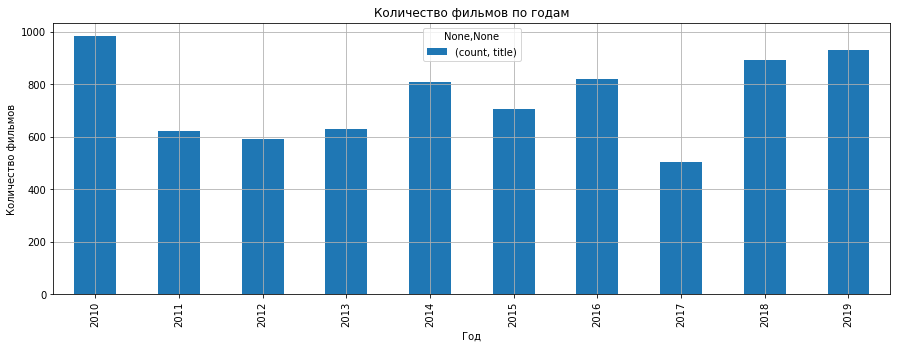

In [44]:
data_for_merge1 = merged_data.pivot_table(index = "year", values = "title", aggfunc = ["count"]).plot(kind = "bar", figsize = (15, 5), grid = True)
plt.xlabel("Год")
plt.ylabel("Количество фильмов") 
plt.title("Количество фильмов по годам")
plt.show() # построение гистограммы 

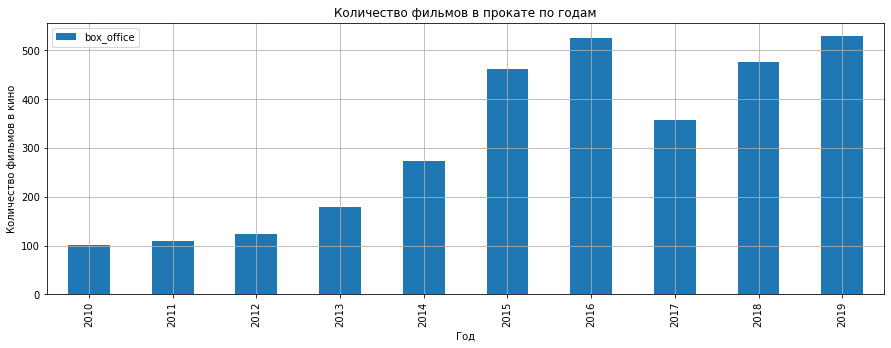

In [45]:
data_for_merge2 = merged_data.query("box_office > 0").pivot_table(index = "year", values = "box_office", aggfunc = "count").plot(kind = "bar", figsize = (15, 5), grid = True)
plt.xlabel("Год")  
plt.ylabel("Количество фильмов в кино") 
plt.title("Количество фильмов в прокате по годам")
plt.show() # построение гистограммы

In [46]:
print(f'Доля фильмов c информацией о сборах: {merged_data["box_office"].notna().mean():.2f}') # вывод доли фильмов с информацией о сборах

Доля фильмов c информацией о сборах: 0.42


In [47]:
data_pivot = merged_data.pivot_table(index = "year", values = "title", aggfunc = "count") # построение сводной таблицы
data_query = merged_data.query("box_office > 0").pivot_table(index = "year", values = "box_office", aggfunc = "count")
combined_data = pd.concat([data_pivot, data_query], axis = 1).fillna(0)
combined_data.columns = ["count", "box_office"]
print(combined_data) # проверка результата

      count  box_office
year                   
2010    985         101
2011    622         109
2012    593         123
2013    630         179
2014    807         273
2015    705         462
2016    818         525
2017    505         357
2018    891         475
2019    930         530


In [48]:
combined_data["part_of"] = (combined_data["box_office"] / combined_data["count"] * 100) # добавление столбца с долей фильмов в прокате в кинотеатрах от всего количества фильмов в прокате
display(combined_data) # проверка результата 

,count,box_office,part_of
year,,,
2010,985,101,10.253807
2011,622,109,17.524116
2012,593,123,20.741990
2013,630,179,28.412698
2014,807,273,33.828996
2015,705,462,65.531915
2016,818,525,64.180929
2017,505,357,70.693069
2018,891,475,53.310887


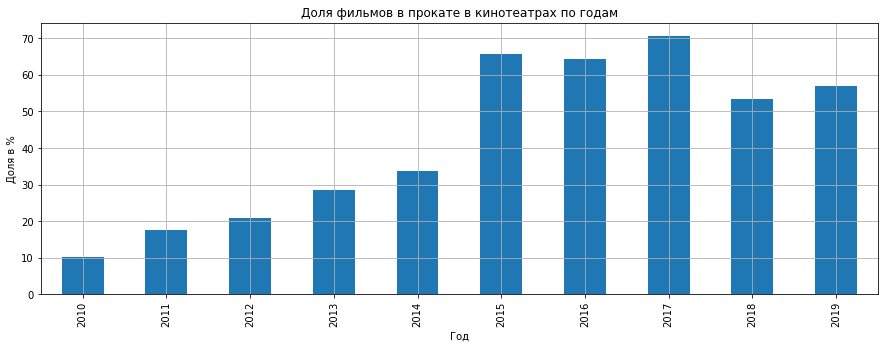

In [49]:
combined_data["part_of"].plot(kind = "bar", figsize = (15, 5), grid = True, title = "Доля фильмов в прокате в кинотеатрах по годам")
plt.ylabel("Доля в %")
plt.xlabel("Год")
plt.show()

2010 год зафиксировано минимальное количество фильмов, показанных в кинотеатрах. С 2011 по 2016 годы наблюдался постепенный рост этого показателя. В 2017 году был достигнут максимум — более 70% фильмов, выпущенных в прокат, были показаны в кинотеатрах. В 2018 и 2019 годах произошел спад до 53%. В 2020 году снова наблюдается небольшое повышение до 58%. Динамика демонстрирует как значительное увеличение, так и последующий спад, с незначительным восстановлением

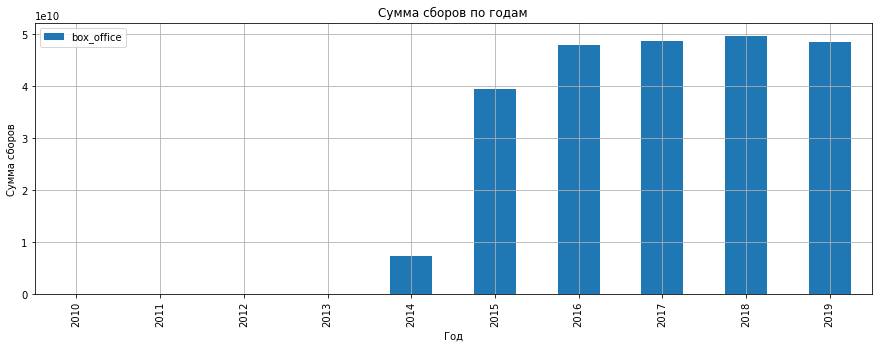

In [50]:
merged_data.query("box_office > 0").pivot_table(index = "year", values = "box_office", aggfunc = "sum").plot(kind = "bar", figsize = (15, 5), grid = True)
plt.title("Сумма сборов по годам")
plt.ylabel("Сумма сборов")
plt.xlabel("Год")
plt.show()

Самый низкий показатель наблюдается в 2014 года, после чего можно резкую и положительную динамику, в 2016 году рост закончился, с 2016 по 2019 сборы держатся примерно в одном и том же диапазоне.

In [51]:
pivot_box_office = merged_data.groupby("year")["box_office"].sum() # построение сводной таблицы
display(pivot_box_office)

merged_data.pivot_table(index = "year", values = "box_office", aggfunc = ["mean", "median"]) # поиск средних и медианных значений для каждого года

year
2010    2.428654e+06
2011    1.410276e+07
2012    6.955423e+06
2013    2.979971e+07
2014    7.444952e+09
2015    3.949737e+10
2016    4.786630e+10
2017    4.856371e+10
2018    4.966840e+10
2019    4.842571e+10
Name: box_office, dtype: float64

,mean,median
,box_office,box_office
year,,
2010,2.313004e+04,1700.000
2011,1.293832e+05,3000.000
2012,5.433924e+04,5660.000
2013,1.619549e+05,3522.500
2014,2.668442e+07,18160.000
2015,8.494057e+07,4920933.000
2016,9.100057e+07,3846679.410
2017,1.360328e+08,9968340.000


Средние и медианные сильно отличаются, вероятно, в данных есть аномалии.

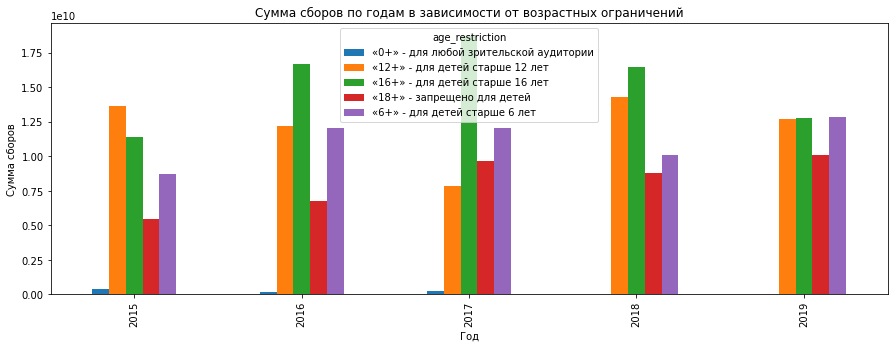

In [53]:
merged_data.query("2015 <= year <= 2019").pivot_table(index = "year", columns = "age_restriction", values = "box_office", aggfunc = "sum").plot(kind = "bar", figsize = (15, 5))
plt.title("Сумма сборов по годам в зависимости от возрастных ограничений")
plt.ylabel("Сумма сборов")
plt.xlabel("Год")
plt.show()

Самые высокие сборы наблюдаются у фильмов с рейтингом 16+, следом идут картины с рейтингами 12+ и 18+. Фильмы для детей (0+) имеют самые скромные сборы. Средние и медианные значения значимо различаются, что может указывать на наличие аномалий в данных. В 2014 году отмечен самый низкий показатель сборов, после чего начинается резкий рост, который заканчивается в 2016 году. С 2016 по 2019 годы сборы остаются в одном диапазоне. В 2010 году зафиксировано минимальное количество фильмов, показанных в кинотеатрах, с постепенным ростом с 2011 по 2016 годы. В 2017 году достигнут максимум — более 70% фильмов показаны в кинотеатрах, затем следует спад до 53% в 2018 и 2019 годах. В 2020 году наблюдается небольшое повышение до 58%. Таким образом, динамика сбора и показов фильмов демонстрирует как прирост, так и последующий спад с небольшим восстановлением.

###  Исследование фильмов с господдержкой



In [54]:
data_for_analysis = merged_data.query("financing_source != 'отсутствует'").reset_index() # делаем срез
display(data_for_analysis) # проверка результата

,index,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,...,nonrefundable_support,budget,financing_source,ratings,genres,box_office,year,first_director,first_genres,goverment_support
0,1281,Пока еще жива,111005313,2013-10-11 12:00:00,Художественный,"АНО содействия развитию кинематографии ""Ангел-...",Россия,А.Атанесян,"А.Атанесян, М.Бабаханов, Р.Бутко",«16+» - для детей старше 16 лет,...,26500000.0,79411900.0,Министерство культуры,8.1,"драма,мелодрама",3.653536e+05,2013,А.Атанесян,драма,33.370314
1,1448,Бесславные придурки,111003314,2014-03-28 12:00:00,Художественный,"ООО ""Компания ""АТК-Студио""",Россия,А.Якимчук,А.Тютрюмов,«12+» - для детей старше 12 лет,...,26000000.0,37142857.0,Министерство культуры,NaN,отсутствует,2.814000e+04,2014,А.Якимчук,отсутствует,70.000000
2,1498,Невидимки,111004213,2013-09-10 12:00:00,Художественный,"ООО ""Компания ""РЕАЛ-ДАКОТА""",Россия,"Р.Давлетьяров, С.Комаров","Р.Давлетьяров, А.Котелевский, А.Олейников",«12+» - для детей старше 12 лет,...,107847945.0,176023490.0,Фонд кино,5.3,"комедия,фантастика",1.995703e+07,2013,Р.Давлетьяров,комедия,61.269064
3,1524,БЕРЦЫ,111004314,2014-05-05 12:00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,Е.Миндадзе (псевдоним Катя Шагалова),Л.Антонова,«16+» - для детей старше 16 лет,...,28000000.0,40574140.0,Министерство культуры,4.2,драма,5.591750e+04,2014,Е.Миндадзе (псевдоним Катя Шагалова),драма,69.009473
4,1792,Братья Ч,111004414,2014-04-23 12:00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,М.Угаров,"А.Миндадзе, Л.Антонова",«16+» - для детей старше 16 лет,...,25000000.0,40015122.0,Министерство культуры,6.4,драма,2.321000e+05,2014,М.Угаров,драма,62.476381
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,7464,Союз спасения,111022019,2019-12-26 12:00:00,Художественный,"ЗАО ""Дирекция кино""",Россия,А.Кравчук,"А.Максимов, К.Эрнст",«12+» - для детей старше 12 лет,...,400000000.0,980000000.0,Фонд кино,6.0,"история,биография,драма",7.177032e+08,2019,А.Кравчук,история,51.020408
328,7466,Иван Царевич и Серый Волк 4,114005019,2019-12-20 12:00:00,Анимационный,"ООО ""Студия анимационного кино ""Мельница""",Россия,"Д.Шмидт, К.Феоктистов","С.Сельянов, А.Боярский",«6+» - для детей старше 6 лет,...,0.0,190000000.0,Фонд кино,6.7,"мультфильм,приключения,семейный",5.010692e+08,2019,Д.Шмидт,мультфильм,52.631579
329,7474,Вторжение,111022519,2019-12-23 12:00:00,Художественный,"ООО ""Арт Пикчерс Студия"", ООО ""Водород 2011""",Россия,Ф.Бондарчук,"Ф.Бондарчук, М.Врубель, А.Андрющенко, Д.Рудовский",«12+» - для детей старше 12 лет,...,400000000.0,944000000.0,Фонд кино,5.7,"фантастика,боевик",NaN,2019,Ф.Бондарчук,фантастика,52.966102
330,7476,Я свободен,111023019,2019-12-26 12:00:00,Художественный,"АО ""ТПО ""Киностудия им. М.Горького""",Россия,И.Северов,С.Зернов,«12+» - для детей старше 12 лет,...,30000000.0,46154000.0,Министерство культуры,5.9,драма,NaN,2019,И.Северов,драма,64.999783


Для дальнейшей работы создал отдельный датасет с строками где поддержка государства !=0

In [55]:
data_for_analysis["total_goverment_support"] = data_for_analysis["refundable_support"] + data_for_analysis["nonrefundable_support"]
display(data_for_analysis.head(25)) # создание отдельного столбца с суммарной поддержкой от гос-ва                                                                                                                                                                                              

,index,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,...,budget,financing_source,ratings,genres,box_office,year,first_director,first_genres,goverment_support,total_goverment_support
0,1281,Пока еще жива,111005313,2013-10-11 12:00:00,Художественный,"АНО содействия развитию кинематографии ""Ангел-...",Россия,А.Атанесян,"А.Атанесян, М.Бабаханов, Р.Бутко",«16+» - для детей старше 16 лет,...,79411900.0,Министерство культуры,8.1,"драма,мелодрама",365353.6,2013,А.Атанесян,драма,33.370314,26500000.0
1,1448,Бесславные придурки,111003314,2014-03-28 12:00:00,Художественный,"ООО ""Компания ""АТК-Студио""",Россия,А.Якимчук,А.Тютрюмов,«12+» - для детей старше 12 лет,...,37142857.0,Министерство культуры,NaN,отсутствует,28140.0,2014,А.Якимчук,отсутствует,70.000000,26000000.0
2,1498,Невидимки,111004213,2013-09-10 12:00:00,Художественный,"ООО ""Компания ""РЕАЛ-ДАКОТА""",Россия,"Р.Давлетьяров, С.Комаров","Р.Давлетьяров, А.Котелевский, А.Олейников",«12+» - для детей старше 12 лет,...,176023490.0,Фонд кино,5.3,"комедия,фантастика",19957031.5,2013,Р.Давлетьяров,комедия,61.269064,107847945.0
3,1524,БЕРЦЫ,111004314,2014-05-05 12:00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,Е.Миндадзе (псевдоним Катя Шагалова),Л.Антонова,«16+» - для детей старше 16 лет,...,40574140.0,Министерство культуры,4.2,драма,55917.5,2014,Е.Миндадзе (псевдоним Катя Шагалова),драма,69.009473,28000000.0
4,1792,Братья Ч,111004414,2014-04-23 12:00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,М.Угаров,"А.Миндадзе, Л.Антонова",«16+» - для детей старше 16 лет,...,40015122.0,Министерство культуры,6.4,драма,232100.0,2014,М.Угаров,драма,62.476381,25000000.0
5,1854,Тайна Сухаревой башни. Чародей равновесия,114000115,2015-02-18 12:00:00,Анимационный,"ООО ""Студия ""Мастер-Фильм""",Россия,С.Серегин,А.Герасимов,«6+» - для детей старше 6 лет,...,51850000.0,Министерство культуры,6.1,"мультфильм,фэнтези,история",15078858.6,2015,С.Серегин,мультфильм,48.216008,25000000.0
6,1870,А зори здесь тихие..._,111002915,2015-03-16 12:00:00,Художественный,"ООО ""Компания ""Реал-Дакота""",Россия,Р.Давлетьяров,отсутствует,«12+» - для детей старше 12 лет,...,220588394.0,Фонд кино,8.5,"драма,военный,история",249166767.7,2015,Р.Давлетьяров,драма,67.999951,150000000.0
7,1871,Две женщины,111013714,2014-10-02 12:00:00,Художественный,"ООО ""Продюсерский Центр ""Хорошо Продакшн"", Rez...","Россия, Франция, Латвия",В.Глаголева,Н.Иванова,«12+» - для детей старше 12 лет,...,86210067.0,"Министерство культуры, Фонд кино",6.7,драма,4731239.5,2014,В.Глаголева,драма,53.940683,46502299.0
8,1903,Призрак_.,111001815,2015-03-02 12:00:00,Художественный,"ООО ""Водород 2011""",Россия,А.Войтинский,С.Сельянов,«6+» - для детей старше 6 лет,...,139551503.0,Фонд кино,7.0,"триллер,боевик,приключения",352804320.4,2015,А.Войтинский,триллер,53.743599,75000000.0
9,1912,Ведьма .,111002215,2015-03-05 12:00:00,Художественный,"ООО ""Кинокомпания ""Ракурс""",Россия,Д.Федоров,В.Сидоренко,«16+» - для детей старше 16 лет,...,48571430.0,Министерство культуры,7.4,"фэнтези,приключения,драма",51907.5,2015,Д.Федоров,фэнтези,69.999998,34000000.0


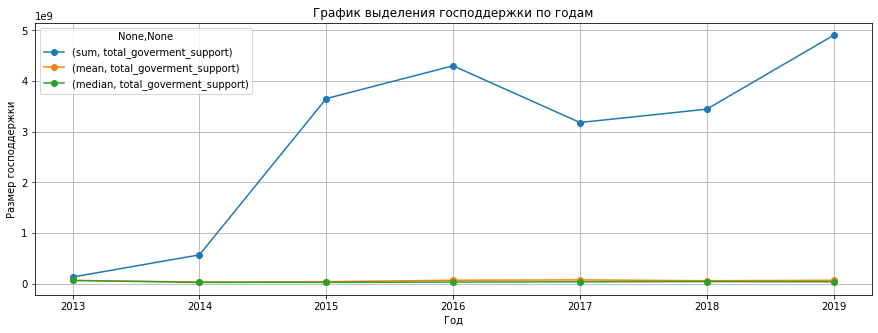

In [56]:
data_for_analysis.pivot_table(index = "year", values = "total_goverment_support", aggfunc = ["sum", "mean", "median"]).plot(style ="o-", grid = True, figsize = (15,5))
plt.title("График выделения господдержки по годам")
plt.ylabel("Размер господдержки")
plt.xlabel("Год")
plt.show()

Государственная поддержка начала активно расти с 2014 года, с 2016 по 2017 наблюдался небольшой спад в финансировании который сменился еле заметным увеличением поддержки до 2018 года, пиковое значение достигнуто в 2019.

In [57]:
data_for_analysis["cashback"]= data_for_analysis["box_office"] - data_for_analysis["budget"] # создание столбца окупаемости
display(data_for_analysis) # проверка результата

,index,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,...,financing_source,ratings,genres,box_office,year,first_director,first_genres,goverment_support,total_goverment_support,cashback
0,1281,Пока еще жива,111005313,2013-10-11 12:00:00,Художественный,"АНО содействия развитию кинематографии ""Ангел-...",Россия,А.Атанесян,"А.Атанесян, М.Бабаханов, Р.Бутко",«16+» - для детей старше 16 лет,...,Министерство культуры,8.1,"драма,мелодрама",3.653536e+05,2013,А.Атанесян,драма,33.370314,26500000.0,-7.904655e+07
1,1448,Бесславные придурки,111003314,2014-03-28 12:00:00,Художественный,"ООО ""Компания ""АТК-Студио""",Россия,А.Якимчук,А.Тютрюмов,«12+» - для детей старше 12 лет,...,Министерство культуры,NaN,отсутствует,2.814000e+04,2014,А.Якимчук,отсутствует,70.000000,26000000.0,-3.711472e+07
2,1498,Невидимки,111004213,2013-09-10 12:00:00,Художественный,"ООО ""Компания ""РЕАЛ-ДАКОТА""",Россия,"Р.Давлетьяров, С.Комаров","Р.Давлетьяров, А.Котелевский, А.Олейников",«12+» - для детей старше 12 лет,...,Фонд кино,5.3,"комедия,фантастика",1.995703e+07,2013,Р.Давлетьяров,комедия,61.269064,107847945.0,-1.560665e+08
3,1524,БЕРЦЫ,111004314,2014-05-05 12:00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,Е.Миндадзе (псевдоним Катя Шагалова),Л.Антонова,«16+» - для детей старше 16 лет,...,Министерство культуры,4.2,драма,5.591750e+04,2014,Е.Миндадзе (псевдоним Катя Шагалова),драма,69.009473,28000000.0,-4.051822e+07
4,1792,Братья Ч,111004414,2014-04-23 12:00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,М.Угаров,"А.Миндадзе, Л.Антонова",«16+» - для детей старше 16 лет,...,Министерство культуры,6.4,драма,2.321000e+05,2014,М.Угаров,драма,62.476381,25000000.0,-3.978302e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,7464,Союз спасения,111022019,2019-12-26 12:00:00,Художественный,"ЗАО ""Дирекция кино""",Россия,А.Кравчук,"А.Максимов, К.Эрнст",«12+» - для детей старше 12 лет,...,Фонд кино,6.0,"история,биография,драма",7.177032e+08,2019,А.Кравчук,история,51.020408,500000000.0,-2.622968e+08
328,7466,Иван Царевич и Серый Волк 4,114005019,2019-12-20 12:00:00,Анимационный,"ООО ""Студия анимационного кино ""Мельница""",Россия,"Д.Шмидт, К.Феоктистов","С.Сельянов, А.Боярский",«6+» - для детей старше 6 лет,...,Фонд кино,6.7,"мультфильм,приключения,семейный",5.010692e+08,2019,Д.Шмидт,мультфильм,52.631579,100000000.0,3.110692e+08
329,7474,Вторжение,111022519,2019-12-23 12:00:00,Художественный,"ООО ""Арт Пикчерс Студия"", ООО ""Водород 2011""",Россия,Ф.Бондарчук,"Ф.Бондарчук, М.Врубель, А.Андрющенко, Д.Рудовский",«12+» - для детей старше 12 лет,...,Фонд кино,5.7,"фантастика,боевик",NaN,2019,Ф.Бондарчук,фантастика,52.966102,500000000.0,NaN
330,7476,Я свободен,111023019,2019-12-26 12:00:00,Художественный,"АО ""ТПО ""Киностудия им. М.Горького""",Россия,И.Северов,С.Зернов,«12+» - для детей старше 12 лет,...,Министерство культуры,5.9,драма,NaN,2019,И.Северов,драма,64.999783,30000000.0,NaN


Аналогично предыдущим расчетам создаю отдельный столбец для проверки окупаемости

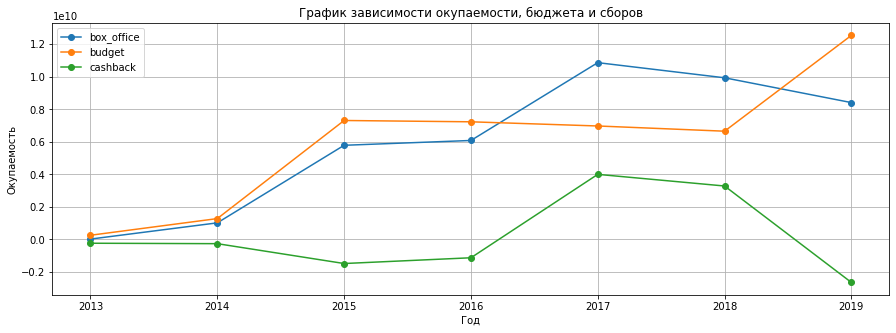

In [58]:
data_for_analysis.pivot_table(index = "year", values = ("box_office", "budget", "cashback"), aggfunc = "sum").plot(style = "o-", grid = True, figsize=(15,5), title = "График зависимости окупаемости, бюджета и сборов")
plt.xlabel("Год")
plt.ylabel("Окупаемость")
plt.show() # построение графика окупаемости

Фильмы с гос поддержкой редко окупаются.

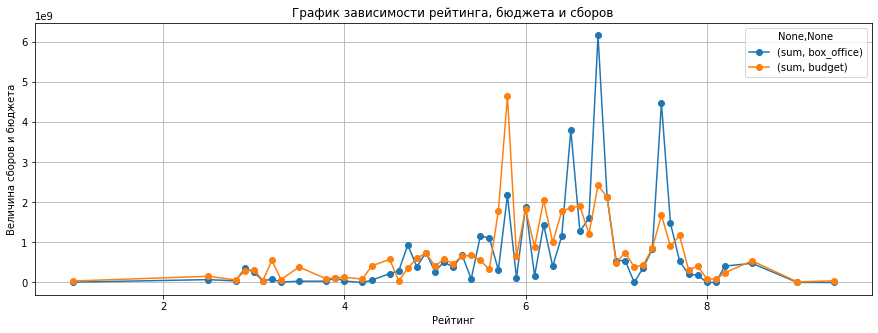

In [59]:
data_for_analysis.pivot_table(index = "ratings", values = ("box_office", "budget"), aggfunc = ["sum"]).plot(style = "o-",grid = True, figsize = (15,5), title = "График зависимости рейтинга, бюджета и сборов")
plt.xlabel("Рейтинг")
plt.ylabel("Величина сборов и бюджета")
plt.show()

Фильмы с рейтингом выше 7.8 имели небольшой бюджет и низкие сборы.
Самые большие сборы у фильмов с рейтингом чуть ниже 7, бюджет которых составлял около 2.3, а сборы превышали 4.
Фильмы с самым высоким бюджетом (около 5) имели средние сборы (2.1) и рейтинг около 6.
Вывод: Бюджет и сборы не влияют на рейтинг фильмов.

### Выводы

На первом этапе анализа данных были объединены две таблицы и обработаны типы данных, заполнены пропуски в ключевых столбцах. Неявные дубликаты были обработаны, а категориальные значения стандартизированы. В количественных данных были выявлены аномалии и заполнены нулевые значения в бюджете. Добавлены новые столбцы с информацией о годе проката, главном режиссёре и основном жанре фильма.

В ходе исследовательского анализа установлено, что наибольшее количество фильмов вышло в прокат в 2010 году, с последующим спадом и подъемом с 2018 года. Фильмы с возрастным ограничением 16+ собирали наибольшие суммы в прокате, тогда как мультфильмы (0+) имели наименьшие сборы.

Анализ государственной поддержки показал рост с 2014 года до пика в 2019, однако средние значения и медиана оставались стабильными, что указывает на точечную поддержку крупных фильмов. Окупаемость фильмов с гос поддержкой оказалась низкой и не зависела от бюджета или сборов.

Рейтинг фильмов показал, что высокие рейтинги (от 7.8) соответствуют небольшому бюджету и низким сборам. Наибольшие сборы наблюдались у фильмов с рейтингом чуть ниже 7 и бюджетом около 2.3. Следовательно, бюджет не влияет на рейтинг или сборы фильмов.